# Predikce polarity systémové odchylky (SO)

Tento notebook na zaklade minutových hodnot SO vytvořit predikční model znaménka SO
 na 2 kroky dopředu (tj. +15 min a +30 min).

Jako model je natrénována Long Short-Term Memory (LSTM) Recurrent Neural Network.
V základu k tomu jsou využity tři knihovny:
- scikit-learn jakožto standardní ML knihovna,
- PyTorch jakožto knihovna zaměřená na tenzorové výpočty a neurální sítě,
- Skorch, zábavná knihovnička, která PyTorch objektům přidává API scikit-learn

Data manipulation je primárně dělaná v NumPy a Pandas.

Notebook obsahuje:
- načtení dat a úvodní zpracování
- resampling, feature engineering
  - sezonnost
  - casove trendy
  - vytvoření targetů
  - skalovani
- data jsou uzpusobeny formatu pro LSTM (v každém čase je vstupem sekvence jednotlivých událostí), a rozdelena na train-test data
- pomoci cross-validace jsou vyzkouseny ruzne architektury LSTM (proměnná velikost skryté vrstvy, počet vrstev)
- nejlepsi natrenovany model je ulozen pro budouci pouziti
- jsou urceny metriky nejlepsiho modelu

> **Poznámka:** je potřeba mít k dispozici CSV soubor s daty (čas + SO).


## Module imports

In [1]:
# standard import
import joblib
from typing import Literal, List, Optional, Tuple
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
# data handling
import numpy as np
import pandas as pd
# scikit learn for machine learning
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
# framework for creation of neural networks
import torch
from torch import nn
# library that gives sklearn interface to pyTorch objects (to call sklearn method on Neural Networks)
from skorch.callbacks import EarlyStopping
from skorch.classifier import NeuralNetClassifier
# standard plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# setting a device for pyTorch to a graphical processor if available
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

header = pd.read_csv(
    'data.csv',
    sep=';',
    nrows=1
)
header

,Verze dat,Od,Do,Agregační funkce,Agregace,Unnamed: 5
0,reálná data,01.03.2025 00:00:00,31.08.2025 23:59:59,agregace průměr,minuta,NaN


## Data read and basic processing

In [2]:
raw_data = pd.read_csv(
        'data.csv',
        sep=';',
        skiprows=2,
        usecols=['Datum', 'Aktuální odchylka [MW]']
    ).rename({
            'Datum': 'TMST',
            'Aktuální odchylka [MW]' : 'SO'
        },
        axis='columns'
    )
# set TMST to datetime and make it index
raw_data['TMST'] = pd.to_datetime(
        raw_data['TMST'],
        format='%d.%m.%Y %H:%M',
        errors='raise'
    )
raw_data = raw_data.set_index('TMST').sort_index()

full_range = pd.date_range(
        start=raw_data.index.min(),
        end=raw_data.index.max(),
        freq="min"
    )
full_range.difference(raw_data.index)
data = pd.DataFrame(index=full_range)
data['SO'] = raw_data['SO']

# fill in missing data (forward only)
data = data.interpolate(limit_direction="forward")
display(data.describe(include='all'))

,SO
count,251824.000000
mean,-17.243347
std,98.876502
min,-2609.313721
25%,-72.772381
50%,-19.073986
75%,35.050224
max,1509.559326


## Class that calculates and adds Time Features to the input data

In [3]:
class SOFeatureAndTargetMatrix:
    """
    Class for constructing a feature matrix and target labels from a
    time series containing 'SO' column.

    Attributes:
        df (pd.DataFrame): Input dataframe with DatetimeIndex and 'SO' column.
        freq (str): Resampling frequency for time features.
        trend_windows (List[Tuple[int, str]]): List of window lengths and units for trend features.
        lags (List[int]): List of lag steps to include as features.
        roll_windows (List[int]): List of rolling window sizes for mean/std features.
        feature_matrix (Optional[pd.DataFrame]): Constructed feature matrix with target labels.
    """
    def __init__(
        self,
        input_data: pd.DataFrame,
        *,
        freq: str = "15min",
        trend_windows: List[Tuple[int, str]] = [(30, "min"), (60, "min")],
        lags: List[int] = list(range(1, 6)),
        roll_windows: List[int] = list(range(4, 13, 4)),
    ):
        """
        Initialize the SOFeatureAndTargetMatrix with input data and parameters.

        Args:
            input_data (pd.DataFrame): Dataframe with DatetimeIndex and 'SO' column.
            freq (str, optional): Resampling frequency. Defaults to "15min".
            trend_windows (List[Tuple[int, str]], optional): Trend feature windows. Defaults to [(30, "min"), (60, "min")].
            lags (List[int], optional): Lags to compute. Defaults to range(1, 6).
            roll_windows (List[int], optional): Rolling window sizes. Defaults to range(4, 13, 4).

        Raises:
            RuntimeError: If input_data index is not DatetimeIndex or 'SO' column is missing.
        """
        if not isinstance(input_data.index, pd.DatetimeIndex):
            raise RuntimeError("Input data dataframe must have DatetimeIndex.")
        if "SO" not in input_data.columns:
            raise RuntimeError("Input data must contain 'SO' column.")

        self.df = input_data
        self.freq = freq
        self.trend_windows = trend_windows
        self.lags = lags
        self.roll_windows = roll_windows
        self.feature_matrix: Optional[pd.DataFrame] = None

    # ---------- static helper methods ----------
    @staticmethod
    def add_lags_and_rolls(
        df: pd.DataFrame,
        lags: List[int],
        roll_windows: List[int],
        col: str = "SO"
    ) -> pd.DataFrame:
        """
        Add lag and rolling statistics features to the dataframe.

        Args:
            df (pd.DataFrame): Input dataframe.
            lags (List[int]): List of lag steps.
            roll_windows (List[int]): List of rolling window sizes.
            col (str, optional): Column to use. Defaults to "SO".

        Returns:
            pd.DataFrame: DataFrame with added lag and rolling features.
        """
        output = df.copy()
        for l in lags:
            output[f"lag_{l}"] = output[col].shift(l)
        for w in roll_windows:
            output[f"roll_mean_{w}"] = output[col].shift(1).rolling(w).mean()
            output[f"roll_std_{w}"] = output[col].shift(1).rolling(w).std()
        return output

    @staticmethod
    def add_seasonal_features(
        df: pd.DataFrame
    ) -> pd.DataFrame:
        """
        Add seasonal time features to the dataframe including:
        - Time of day (sin/cos)
        - Day of week (one-hot)
        - Month (one-hot)
        - Day of month (sin/cos)
        - Day of year (sin/cos)

        Args:
            df (pd.DataFrame): Input dataframe.

        Returns:
            pd.DataFrame: DataFrame with added seasonal features.
        """
        output = df.copy()
        # --- Time of day features ---
        tod = 2 * np.pi * (df.index.hour * 60 + df.index.minute) / 1440
        output["sin_tod"] = np.sin(tod)
        output["cos_tod"] = np.cos(tod)
        # --- Day of week features ---
        output["day_of_week"] = df.index.dayofweek
        for d in range(7):
            output[f"dow_{d}"] = (output["day_of_week"] == d).astype(int)
        # --- Day of month features ---
        output["day_of_month"] = df.index.day
        month = df.index.month
        year = df.index.year
        days_in_month = \
            np.where(month.isin([1, 3, 5, 7, 8, 10, 12]), 31,
            np.where(month.isin([4, 6, 9, 11]), 30,
            np.where(((year % 4 == 0) & ((year % 100 != 0) | (year % 400 == 0))), 29, 28))
        )
        angle = 2 * np.pi * (output["day_of_month"] - 1) / days_in_month
        output["sin_dom"] = np.sin(angle)
        output["cos_dom"] = np.cos(angle)
        # --- Month features ---
        # output["month"] = df.index.month
        # for m in range(1, 13):
        #     output[f"month_{m}"] = (output["month"] == m).astype(int)
        # --- Day of year features ---
        doy = df.index.dayofyear
        output["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
        output["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)
        
        
        return output

    @staticmethod
    def trend_features(
        df: pd.DataFrame,
        *,
        col: str = "SO",
        freq: str = "15min",
        window_len: int = 30,
        window_len_unit: str = "min",
        degree: int = 2,
    ) -> pd.DataFrame:
        """
        Compute polynomial trend features and derivatives for a time series.

        Args:
            df (pd.DataFrame): Input dataframe.
            col (str, optional): Column name. Defaults to "SO".
            freq (str, optional): Frequency for resampling. Defaults to "15min".
            window_len (int, optional): Window length for trend. Defaults to 30.
            window_len_unit (str, optional): Unit of window length. Defaults to "min".
            degree (int, optional): Polynomial degree. Defaults to 2.

        Returns:
            pd.DataFrame: DataFrame with polynomial coefficients and derivatives.

        Raises:
            ValueError: If the series is shorter than window length.
        """
        ts = df[col].asfreq(freq)
        values = ts.values
        n = len(values)
        timestamps = (ts.index.view(np.int64) / 1e9) / 60
        
        if n < window_len:
            raise ValueError("Series is shorter than window length.")
        shape = (n - window_len + 1, window_len)
        strides = (values.strides[0], values.strides[0])
        windows = np.lib.stride_tricks.as_strided(values, shape=shape, strides=strides)
        time_windows = np.lib.stride_tricks.as_strided(
            timestamps,
            shape=shape,
            strides=(timestamps.strides[0], timestamps.strides[0])
        )
        time_windows = time_windows - time_windows[:, [0]]

        coefs = np.empty((windows.shape[0], degree + 1))
        deriv1 = np.empty(windows.shape[0])
        deriv2 = np.empty(windows.shape[0])

        for i in range(windows.shape[0]):
            y = windows[i]
            x = time_windows[i]
            if np.any(np.isnan(y)):
                coefs[i, :] = np.nan
                deriv1[i] = np.nan
                deriv2[i] = np.nan
                continue
            p = np.polyfit(x, y, degree)
            coefs[i, :] = p
            x_t = x[-1]
            dp = np.polyder(p, 1)
            ddp = np.polyder(p, 2)
            deriv1[i] = np.polyval(dp, x_t)
            deriv2[i] = np.polyval(ddp, x_t)

        pad = window_len - 1
        coefs = np.vstack([np.full((pad, degree + 1), np.nan), coefs])
        deriv1 = np.concatenate([np.full(pad, np.nan), deriv1])
        deriv2 = np.concatenate([np.full(pad, np.nan), deriv2])

        output = pd.DataFrame(index=ts.index)
        for j in range(degree + 1):
            output[f"poly{degree}_freq{freq}_window{window_len}{window_len_unit}_coef{j}"] = coefs[:, j]
        output[f"poly{degree}_freq{freq}_window{window_len}{window_len_unit}_deriv1"] = deriv1
        output[f"poly{degree}_freq{freq}_window{window_len}{window_len_unit}_deriv2"] = deriv2

        return output

    # ---------- feature builders ----------
    def build_time_features(self) -> pd.DataFrame:
        """
        Build time-based features including lags, rolling stats, seasonal, and trend features.

        Returns:
            pd.DataFrame: DataFrame containing all features.
        """
        output = self.df.copy().resample(self.freq, label="right").mean()
        output = self.add_lags_and_rolls(output, self.lags, self.roll_windows)
        output = self.add_seasonal_features(output)
        for len_, len_unit in self.trend_windows:
            print(f"adding trend features for {len_} {len_unit}")
            features = self.trend_features(
                self.df, freq=self.freq, window_len=len_, window_len_unit=len_unit
            )
            output = output.join(features)
        return output.dropna()

    def create_feature_matrix_with_targets(self) -> pd.DataFrame:
        """
        Construct the feature matrix and add t+1 and t+2 target columns.

        Returns:
            pd.DataFrame: Feature matrix with target labels.
        """
        self.feature_matrix = self.build_time_features()
        self.feature_matrix["t+1"] = (
            self.feature_matrix["SO"]
            .shift(-1)
            .apply(np.sign)
            .replace({-1.0: 0.0, 0.0: 0.0, 1.0: 1.0})
            .astype("Int64")
        )
        self.feature_matrix["t+2"] = (
            self.feature_matrix["SO"]
            .shift(-2)
            .apply(np.sign)
            .replace({-1.0: 0.0, 0.0: 0.0, 1.0: 1.0})
            .astype("Int64")
        )
        self.feature_matrix.dropna(subset=["t+1", "t+2"], inplace=True)
        return self.feature_matrix

## This class reshapes the data to fit into the LSTM model

The class creates input for the LSTM RNN that is used for predictions, creates train-test splits (with respect to time sequence) and rescales the data.

In [ ]:
class SOFeaturesLSTM:
    """
    Class for preparing LSTM input sequences from a feature dataframe.

    Attributes:
        df (pd.DataFrame): Input dataframe containing features and labels.
        feature_cols (List[str]): Columns to use as input features.
        label_cols (List[str]): Columns to use as labels/targets.
        seq_len (int): Sequence length for LSTM input.
        X (Optional[np.ndarray]): LSTM input sequences.
        y (Optional[np.ndarray]): LSTM target sequences.
        X_train (Optional[np.ndarray]): Training input sequences.
        X_test (Optional[np.ndarray]): Test input sequences.
        y_train (Optional[np.ndarray]): Training target sequences.
        y_test (Optional[np.ndarray]): Test target sequences.
        X_train_scaled (Optional[np.ndarray]): Scaled training input sequences.
        X_test_scaled (Optional[np.ndarray]): Scaled test input sequences.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: List[str],
        label_cols: List[str],
        seq_len: int = 24
    ):
        """
        Initialize SOFeaturesLSTM with dataframe, feature/label columns, and sequence length.

        Args:
            df (pd.DataFrame): Input dataframe with feature and label columns.
            feature_cols (List[str]): List of feature column names.
            label_cols (List[str]): List of label column names.
            seq_len (int, optional): Sequence length for LSTM input. Defaults to 24.
        """
        self.df = df
        self.feature_cols = feature_cols
        self.label_cols = label_cols
        self.seq_len = seq_len
        
        # placeholders for LSTM inputs and splits
        self.X: Optional[np.ndarray] = None
        self.y: Optional[np.ndarray] = None
        self.X_train: Optional[np.ndarray] = None
        self.X_test: Optional[np.ndarray] = None
        self.y_train: Optional[np.ndarray] = None
        self.y_test: Optional[np.ndarray] = None
        self.X_train_scaled: Optional[np.ndarray] = None
        self.X_test_scaled: Optional[np.ndarray] = None

    def create_lstm_input(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Create LSTM input sequences from the class dataframe and specified columns.

        Returns:
            Tuple[np.ndarray, np.ndarray]: Tuple containing input sequences X and target sequences y.
        """
        n_samples = self.df.shape[0] - self.seq_len + 1
        df = self.df.reset_index().rename(columns={'index': 'datetime'}).iloc[:n_samples]
        df['datetime'] = df['datetime'].astype('int64')

        features = df[self.feature_cols + ['datetime']].values
        targets = df[self.label_cols].values
        n_features = features.shape[1]

        X = np.lib.stride_tricks.sliding_window_view(features, (self.seq_len, n_features))[::, 0, :]
        y = targets[self.seq_len - 1:]

        self.X = X.astype('float32')
        self.y = y.astype('float32')
        return X, y

    def create_train_test_split(
        self,
        fraction: float = 0.8
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """
        Split LSTM input sequences into training and testing sets.

        Args:
            fraction (float, optional): Fraction of samples to use for training. Defaults to 0.8.

        Returns:
            Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: X_train, X_test, y_train, y_test.

        Raises:
            ValueError: If fraction is not between 0 and 1.
        """
        if fraction > 1 or fraction <= 0:
            raise ValueError("Fraction must be between 0 and 1.")
        if self.X is None or self.y is None:
            self.create_lstm_input()

        n_samples = self.X.shape[0]
        idx_split = int(n_samples * fraction)

        self.X_train = self.X[:idx_split].astype('float32')
        self.X_test = self.X[idx_split:].astype('float32')
        self.y_train = self.y[:idx_split].astype('float32')
        self.y_test = self.y[idx_split:].astype('float32')

        return self.X_train, self.X_test, self.y_train, self.y_test
    
    def rescale_features(
        self,
        scaler=MinMaxScaler
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Rescale feature sequences using a provided scaler (default MinMaxScaler).

        Args:
            scaler (class, optional): Scaler class from sklearn. Defaults to MinMaxScaler.

        Returns:
            Tuple[np.ndarray, np.ndarray]: Scaled X_train and X_test sequences.
        """
        if self.X_train is None:
            self.create_train_test_split()
        n_train_samples, timesteps, n_features = self.X_train.shape
        X_train_2d = self.X_train.reshape(-1, n_features)
        X_test_2d = self.X_test.reshape(-1, n_features)

        feat_scaler = scaler()
        feat_scaler.fit(X_train_2d) #TODO the scaler should be stored alongside the trained model

        self.X_train_scaled = feat_scaler\
            .transform(X_train_2d)\
            .reshape(n_train_samples, timesteps, n_features)\
            .astype('float32')
        self.X_test_scaled = feat_scaler\
            .transform(X_test_2d)\
            .reshape(self.X_test.shape[0], timesteps, n_features)\
            .astype('float32')

        return self.X_train_scaled, self.X_test_scaled

## This class defines the Long-Short Term Memory Recurring Neural Network

In [5]:
class LSTMClassifier(nn.Module):
    """
    LSTM-based classifier for binary classification tasks.

    Attributes:
        bidirectional (bool): Whether LSTM is bidirectional.
        lstm (nn.LSTM): LSTM module for feature sequence processing.
        fc (nn.Linear): Fully connected layer to produce logits.
    """

    def __init__(
        self,
        n_features: int,
        hidden_size: int = 64,
        num_layers: int = 1,
        bidirectional: bool = False,
        dropout: float = 0.4
    ):
        """
        Initialize the LSTMClassifier.

        Args:
            n_features (int): Number of input features per timestep.
            hidden_size (int, optional): Hidden layer size in LSTM. Defaults to 64.
            num_layers (int, optional): Number of LSTM layers. Defaults to 1.
            bidirectional (bool, optional): Use bidirectional LSTM. Defaults to False.
            dropout (float, optional): Dropout between LSTM layers (only if num_layers > 1). Defaults to 0.0.
        """
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        out_dim = hidden_size * (2 if bidirectional else 1)
        # Separate output heads for t+1 and t+2
        self.fc_t1 = nn.Linear(out_dim, 1)
        self.fc_t2 = nn.Linear(out_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the LSTM classifier.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, seq_len, n_features).

        Returns:
            torch.Tensor: Raw logits tensor of shape (batch_size, 2), NOT passed through sigmoid.
        """
        _, (hn, _) = self.lstm(x)  # hn: (num_layers * num_directions, batch, hidden)
        if self.bidirectional:
            last = torch.cat((hn[-2], hn[-1]), dim=1)  # (batch, 2*hidden)
        else:
            last = hn[-1]  # (batch, hidden)

        # Separate outputs for t+1 amd t+2
        logits_t1 = self.fc_t1(last)
        logits_t2 = self.fc_t2(last)

        logits = torch.cat([logits_t1, logits_t2], dim=1)
        return logits

Just a few utility functions

In [6]:
def evaluate(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    f1p = f1_score(y_true, y_pred, pos_label=1)
    f1n = f1_score(y_true, y_pred, pos_label=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    cls_rep = classification_report( y_true, y_pred)
    print(f"=== {label} ===")
    print(f"Accuracy: {acc:.3f}, F1(+): {f1p:.3f}, F1(-): {f1n:.3f}, MCC: {mcc:.3f}")
    print("Confusion matrix:\n", cm)
    print(F"Classification report:\n{cls_rep}\n\n")
    return acc

def save_model(
    model,
    *,
        path: str='',
        mode: Literal['GridSearch', 'NN']='GridSearch'
) -> None:
    if mode=='GridSearch':
        joblib.dump(model, path.join("gridsearch_lstm.pkl"))
    if mode=='NN':
        model.save_params(f_params=path.join("best_lstm_model.pt"))

def load_model(
    *,
    path: str='',
    mode: Literal['GridSearch', 'NN']='GridSearch',
    model: Optional[NeuralNetClassifier]=None
):
    if mode=='GridSearch':
        return joblib.load("gridsearch_lstm.pkl")
    if mode=='NN':
        model.initialize()
        model.load_params(f_params=path.join("best_lstm_model.pt"))
        return model

## Processing data

### Adding time-based features and creating targets

In [7]:
softm = SOFeatureAndTargetMatrix(
    data,
    freq="15min",
    trend_windows=[(15, "min"), (30, "min"), (60, "min"), (120, "min"), (240, "min")],
    lags=[1, 2, 3, 4, 8, 12, 16],
    roll_windows=[4, 8, 12, 16, 20, 24],
)
softm.create_feature_matrix_with_targets()

adding trend features for 15 min
adding trend features for 30 min
adding trend features for 60 min
adding trend features for 120 min
adding trend features for 240 min


,SO,lag_1,lag_2,lag_3,lag_4,lag_8,lag_12,lag_16,roll_mean_4,roll_std_4,...,poly2_freq15min_window120min_coef2,poly2_freq15min_window120min_deriv1,poly2_freq15min_window120min_deriv2,poly2_freq15min_window240min_coef0,poly2_freq15min_window240min_coef1,poly2_freq15min_window240min_coef2,poly2_freq15min_window240min_deriv1,poly2_freq15min_window240min_deriv2,t+1,t+2
2025-03-03 11:45:00,7.973680,37.713175,9.825652,-158.936205,-192.493831,-81.682839,77.461305,1.403815,-75.972802,116.541770,...,126.759129,-0.189065,-0.000067,-0.000038,0.140727,-83.410078,-0.131303,-0.000076,1,1
2025-03-03 12:00:00,40.346568,7.973680,37.713175,9.825652,-158.936205,-132.945613,118.346880,86.733637,-25.855924,89.757095,...,140.824480,-0.138495,-0.000012,-0.000038,0.140294,-84.234916,-0.128615,-0.000075,1,1
2025-03-03 12:15:00,115.867841,40.346568,7.973680,37.713175,9.825652,-275.993645,-174.761050,5.491240,23.964769,17.445263,...,153.574407,-0.089841,0.000041,-0.000035,0.130677,-76.852874,-0.119770,-0.000070,1,1
2025-03-03 12:30:00,73.584886,115.867841,40.346568,7.973680,37.713175,-210.606752,-98.742863,43.506494,50.475316,46.000127,...,164.141533,-0.051121,0.000083,-0.000034,0.126689,-73.896343,-0.115824,-0.000068,1,1
2025-03-03 12:45:00,101.853326,73.584886,115.867841,40.346568,7.973680,-192.493831,-81.682839,77.461305,59.443244,46.179073,...,174.828018,-0.011528,0.000126,-0.000033,0.122584,-70.914624,-0.111650,-0.000065,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-22 19:30:00,-69.331528,-93.927322,-75.036320,-28.856838,-91.262411,-34.341159,-74.633026,-58.069181,-72.270723,30.122563,...,22.607548,0.190211,0.000225,-0.000008,0.032148,-70.734602,-0.024236,-0.000016,0,0
2025-08-22 19:45:00,-78.789569,-69.331528,-93.927322,-75.036320,-28.856838,-81.766430,-13.692454,-5.766206,-66.788002,27.385033,...,9.919057,0.171395,0.000199,-0.000008,0.033177,-71.410049,-0.025267,-0.000016,0,0
2025-08-22 20:00:00,-33.961006,-78.789569,-69.331528,-93.927322,-75.036320,-120.263554,13.283516,32.048510,-79.271184,10.516101,...,-3.137222,0.153202,0.000172,-0.000008,0.034372,-72.392682,-0.026113,-0.000017,0,0
2025-08-22 20:15:00,-62.900745,-33.961006,-78.789569,-69.331528,-93.927322,-77.980217,-87.390677,20.455378,-69.002356,25.462705,...,-15.502276,0.128723,0.000142,-0.000009,0.037880,-74.778826,-0.029738,-0.000019,0,0


### Reshaping data, creating train-test splits and scaling

Selecting a rolling window of 96 records (24 hours) to feed into the model

In [8]:
label_cols = ['t+1', 't+2']
lstm_softm = SOFeaturesLSTM(
    softm.feature_matrix,
    feature_cols=[col for col in softm.feature_matrix.columns if col not in label_cols],
    label_cols=label_cols,
    seq_len=24*4
)
lstm_softm.create_train_test_split(fraction=.95)
lstm_softm.rescale_features()

print(f'X_train_scaled shape: {lstm_softm.X_train_scaled.shape}, dtype {lstm_softm.X_train_scaled.dtype}')
print(f'X_test_scaled shape: {lstm_softm.X_test_scaled.shape}, dtype {lstm_softm.X_test_scaled.dtype}')
print(f'y_train shape: {lstm_softm.y_train.shape}, dtype {lstm_softm.y_train.dtype}')
print(f'y_test shape: {lstm_softm.y_test.shape}, dtype {lstm_softm.y_test.dtype}')

X_train_scaled shape: (15540, 96, 61), dtype float32
X_test_scaled shape: (818, 96, 61), dtype float32
y_train shape: (15540, 2), dtype float32
y_test shape: (818, 2), dtype float32


### creating instance of the NeuralNetClassifier to be trained for predictions and looking for best parameters

In [9]:
early_stop = EarlyStopping(
    monitor='train_loss',  # monitor validation accuracy
    patience=5,
    threshold=1e-4,
    lower_is_better=True
)

net = NeuralNetClassifier(
    module=LSTMClassifier,
    module__n_features=lstm_softm.X_train.shape[2],
    max_epochs=100,
    lr=1e-3,
    optimizer=torch.optim.Adam,
    optimizer__amsgrad=True,
    criterion=nn.BCEWithLogitsLoss,
    device=DEVICE,
    batch_size=64,
    iterator_train__shuffle=True,
    train_split=None,
    verbose=1,
    callbacks=[early_stop]
)

# GridSearchCV with TimeSeriesSplit
lstm_model = GridSearchCV(
    estimator=net,
    cv=TimeSeriesSplit(n_splits=3),
    param_grid={
        'module__hidden_size': [32, 64, 96],
        'module__num_layers': [2, 3, 4],
        'module__bidirectional': [True, False]
    },
    verbose=2,
    scoring='f1_macro'
)


training the network

In [10]:
lstm_model.fit(lstm_softm.X_train_scaled, lstm_softm.y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6703  1.1549
      2        0.6646  0.7412
      3        0.6507  0.7441
      4        0.6304  0.7307
      5        0.6128  0.7309
      6        0.5939  0.7293
      7        0.5734  0.7633
      8        0.5583  0.7669
      9        0.5414  0.7271
     10        0.5403  0.7404
     11        0.5184  0.7170
     12        0.5096  0.7222
     13        0.5016  0.7304
     14        0.4952  0.7398
     15        0.4873  0.7196
     16        0.4873  0.6994
     17        0.4775  0.7272
     18        0.4713  0.7339
     19        0.4652  0.7258
     20        0.4654  0.7033
     21        0.4545  0.7153
     22        0.4604  0.7212
     23        0.4483  0.7113
     24        0.4434  0.7302
     25        0.4413  0.7275
     26        0.4316  0.7334
     27        0.4552  0.7270
     28        0.4298  0.7268
     29        0.4338  0.7149
     30  

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.LSTMClassifier'>,
  module__n_features=61,
),
             param_grid={'module__bidirectional': [True, False],
                         'module__hidden_size': [32, 64, 96],
                         'module__num_layers': [2, 3, 4]},
             scoring='f1_macro', verbose=2)

Best fit network

In [11]:
print(lstm_model.best_params_)
print(lstm_model.best_score_)
model = lstm_model.best_estimator_

{'module__bidirectional': True, 'module__hidden_size': 96, 'module__num_layers': 4}
0.597360754763319


In [12]:
save_model(
    model,
    mode='GridSearch'
)

Best threshold for t+1: 0.176 (TPR=0.786, FPR=0.164)
=== t+1 ===
Accuracy: 0.822, F1(+): 0.697, F1(-): 0.873, MCC: 0.579
Confusion matrix:
 [[504  99]
 [ 47 168]]
Classification report:
              precision    recall  f1-score   support

         0.0       0.91      0.84      0.87       603
         1.0       0.63      0.78      0.70       215

    accuracy                           0.82       818
   macro avg       0.77      0.81      0.79       818
weighted avg       0.84      0.82      0.83       818



Best threshold for t+2: 0.232 (TPR=0.693, FPR=0.207)
=== t+2 ===
Accuracy: 0.765, F1(+): 0.607, F1(-): 0.833, MCC: 0.449
Confusion matrix:
 [[478 125]
 [ 67 148]]
Classification report:
              precision    recall  f1-score   support

         0.0       0.88      0.79      0.83       603
         1.0       0.54      0.69      0.61       215

    accuracy                           0.77       818
   macro avg       0.71      0.74      0.72       818
weighted avg       0.79    

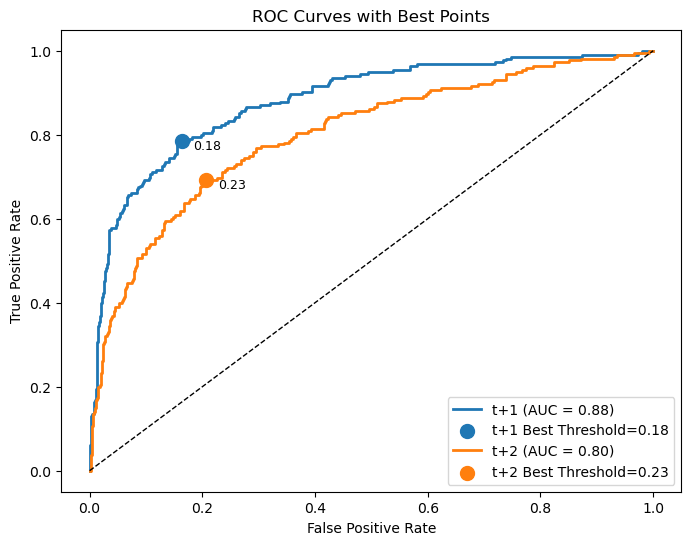

In [13]:
y_prob = lstm_model.predict_proba(lstm_softm.X_test_scaled)[:, 1]
y_pred = np.zeros(y_prob.shape)
roc_data = []

best_thresholds = {}

plt.figure(figsize=(8, 6))

for i, targ in enumerate(['t+1', 't+2']):
    fpr, tpr, thresholds = roc_curve(lstm_softm.y_test[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Compute Youden's J statistic
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_threshold = thresholds[best_idx]
    best_thresholds[targ] = best_threshold
    print(f"Best threshold for {targ}: {best_threshold:.3f} (TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f})")
    
    y_pred[:, i] = (y_prob[:, i] > best_threshold)
    evaluate(lstm_softm.y_test[:, i], y_pred[:, i], targ)
    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f"{targ} (AUC = {roc_auc:.2f})")
    
    # Plot the best point
    plt.scatter(fpr[best_idx], tpr[best_idx], marker='o', s=100, label=f"{targ} Best Threshold={best_threshold:.2f}")
    plt.text(fpr[best_idx]+0.02, tpr[best_idx]-0.02, f"{best_threshold:.2f}", fontsize=9)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves with Best Points")
plt.legend(loc="lower right")
plt.show()
